# Mini-project 2 – Norwegian High School Grade Statistics

**Problem:** There is a public debate about whether standpunkt (teacher) grades are systematically
higher than written exam grades, and whether oral exam grades are often higher than standpunkt.
We explore this gap using data from Udir for Oslo-area schools.

**Data source:** https://www.udir.no/tall-og-forskning/statistikk/statistikk-videregaendeskole/karakterer-vgs/

**Note on the CSV format from Udir:**
Udir exports a wide-format file where each column represents one combination of year, assessment type and metric.
The file is UTF-16 encoded and tab-separated. The code below handles all of this automatically.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV from Udir
# - encoding='utf-16-le' because Udir exports UTF-16 (not standard UTF-8)
# - sep='\t' because columns are separated by tabs
# - skiprows=1 to skip the first 'sep=\t' metadata line Udir adds
# - low_memory=False to avoid mixed-type warnings on wide columns
path = "karakterer_i_videregaaende_skole.csv"
df = pd.read_csv(path, encoding='utf-16-le', sep='\t', skiprows=1, low_memory=False)

print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df[['Fylke', 'EnhetNavn', 'Vurderingsfagnavn']].head(5)

Rows: 15370, Columns: 132


,Fylke,EnhetNavn,Vurderingsfagnavn
0,Alle fylker,Alle skoler,Nyanlegg
1,Alle fylker,Alle skoler,Nyanlegg
2,Oslo,Alle skoler,Nyanlegg
3,Oslo,Sogn videregående skole (Nedlagt),Nyanlegg
4,Alle fylker,Alle skoler,Drift og vedlikehold


In [4]:
# Check data types and unique values in key columns
print("Fylke values:", df['Fylke'].unique())
print("EnhetNivaa values:", df['EnhetNivaa'].unique())

# EnhetNivaa tells us the level:
#   0 = national, all subjects combined
#   1 = national, per subject
#   2 = county level
#   3 = individual school level

Fylke values: <StringArray>
['Alle fylker', 'Oslo']
Length: 2, dtype: str
EnhetNivaa values: [0 1 2 3]


In [2]:
# Filter to Oslo schools only (EnhetNivaa == 3 means individual school level)
df_oslo = df[(df['Fylke'] == 'Oslo') & (df['EnhetNivaa'] == 3)].copy()

print(f"Oslo school rows: {len(df_oslo)}")
print("Oslo schools:", df_oslo['EnhetNavn'].unique())

Oslo school rows: 10074
Oslo schools: <StringArray>
[                        'Sogn videregående skole (Nedlagt)',
                                 'Holtet videregående skole',
                               'Oslo voksenopplæring Sinsen',
                                 'Ulsrud videregående skole',
                                'Stovner videregående skole',
                                  'Kuben videregående skole',
                                'Hersleb videregående skole',
                                 'Ullern videregående skole',
                              'Etterstad videregående skole',
                                'Nydalen videregående skole',
                              'Bjørnholt videregående skole',
                               'Hellerud videregående skole',
                           'Edvard Munch videregående skole',
                                 'Bjerke videregående skole',
                              'Oslo voksenopplæring Helsfyr',
                  

In [3]:
# The data is in wide format – each column is one year + assessment type combination
# Example column name: '2023-24.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter'
# We only want the Snittkarakter (average grade) columns, not the Antall (count) or Brudd columns

id_cols = ['EnhetNavn', 'Vurderingsfagnavn']

snitt_cols = [
    c for c in df_oslo.columns
    if 'Snittkarakter' in c and 'Brudd' not in c
]

print(f"Found {len(snitt_cols)} grade columns")
print("Example:", snitt_cols[:3])

Found 54 grade columns
Example: ['2007-08.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter', '2007-08.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter', '2007-08.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter']


In [11]:
# Reshape from wide to long format so each row is one (school, subject, year, type, grade)
df_long = df_oslo[id_cols + snitt_cols].melt(
    id_vars=id_cols,
    value_vars=snitt_cols,
    var_name='col',
    value_name='Snittkarakter'
)

# Split the column name into year and assessment type
# Column format: '2023-24.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter'
df_long['Skoleaar'] = df_long['col'].str.split('.').str[0]
df_long['Vurderingsform'] = df_long['col'].str.split('.').str[1]

df_long = df_long.drop(columns=['col'])
df_long = df_long.rename(columns={'EnhetNavn': 'Skole', 'Vurderingsfagnavn': 'Fag'})
df_long = df_long[df_long['Skoleaar'] == '2023-24']


print(f"Long format rows: {len(df_long)}")
df_long.head()

Long format rows: 30222


,Skole,Fag,Snittkarakter,Skoleaar,Vurderingsform
483552,Sogn videregående skole (Nedlagt),Nyanlegg,NaN,2023-24,Muntlig eksamen
483553,Sogn videregående skole (Nedlagt),Drift og vedlikehold,NaN,2023-24,Muntlig eksamen
483554,Sogn videregående skole (Nedlagt),Tverrfaglig eksamen anleggsgartner- og idretts...,NaN,2023-24,Muntlig eksamen
483555,Holtet videregående skole,Grunnleggende helsefag,NaN,2023-24,Muntlig eksamen
483556,Oslo voksenopplæring Sinsen,Grunnleggende helsefag,NaN,2023-24,Muntlig eksamen


In [12]:
# Udir uses comma as decimal separator (Norwegian format), so '3,5' must become 3.5
df_long['Snittkarakter'] = (
    df_long['Snittkarakter']
    .astype(str)
    .str.replace(',', '.', regex=False)
)
df_long['Snittkarakter'] = pd.to_numeric(df_long['Snittkarakter'], errors='coerce')

# Drop rows with no grade (many school/subject/year combos have no data)
df_long = df_long.dropna(subset=['Snittkarakter'])

print(f"Rows after cleaning: {len(df_long)}")
print("Assessment types:", df_long['Vurderingsform'].unique())

Rows after cleaning: 3202
Assessment types: ['Muntlig eksamen' 'Skriftlig eksamen' 'Standpunkt']


In [13]:
# Focus on the most recent years to keep the analysis current
recent_years = ['2020-21', '2021-22', '2022-23', '2023-24']
df_recent = df_long[df_long['Skoleaar'].isin(recent_years)]

# Separate the three assessment types
standpunkt = df_recent[df_recent['Vurderingsform'] == 'Standpunkt']
skriftlig  = df_recent[df_recent['Vurderingsform'] == 'Skriftlig eksamen']
muntlig    = df_recent[df_recent['Vurderingsform'] == 'Muntlig eksamen']

# Average across all Oslo schools, subjects and recent years
avg_sp = standpunkt['Snittkarakter'].mean()
avg_sk = skriftlig['Snittkarakter'].mean()
avg_mu = muntlig['Snittkarakter'].mean()

print(f"Oslo average standpunkt grade:     {avg_sp:.2f}")
print(f"Oslo average written exam grade:   {avg_sk:.2f}")
print(f"Oslo average oral exam grade:      {avg_mu:.2f}")
print(f"\nGap standpunkt - written exam:     {avg_sp - avg_sk:.2f}")
print(f"Gap oral exam - standpunkt:        {avg_mu - avg_sp:.2f}")

Oslo average standpunkt grade:     4.25
Oslo average written exam grade:   3.49
Oslo average oral exam grade:      4.41

Gap standpunkt - written exam:     0.76
Gap oral exam - standpunkt:        0.17


In [14]:
# Calculate standpunkt vs written exam gap per subject in Oslo
sp_by_subject = standpunkt.groupby('Fag')['Snittkarakter'].mean()
sk_by_subject = skriftlig.groupby('Fag')['Snittkarakter'].mean()

gap_by_subject = (sp_by_subject - sk_by_subject).dropna().sort_values(ascending=False)

# Keep only top 10 subjects by gap size so the chart is readable
gap_by_subject = gap_by_subject.head(10)

print("Top 10 subjects by standpunkt - written exam gap (Oslo):")
print(gap_by_subject)

Top 10 subjects by standpunkt - written exam gap (Oslo):
Fag
Geofag 2                            2.633333
Medie- og informasjonskunnskap 2    1.583333
Informasjonsteknologi 2             1.296104
Matematikk 1P-Y RM                  1.250000
Tysk nivå III                       1.175000
Matematikk R2                       1.093040
Økonomi og ledelse                  0.998462
Matematikk 1P                       0.971371
Matematikk S2                       0.960507
Økonomistyring                      0.957143
Name: Snittkarakter, dtype: float64


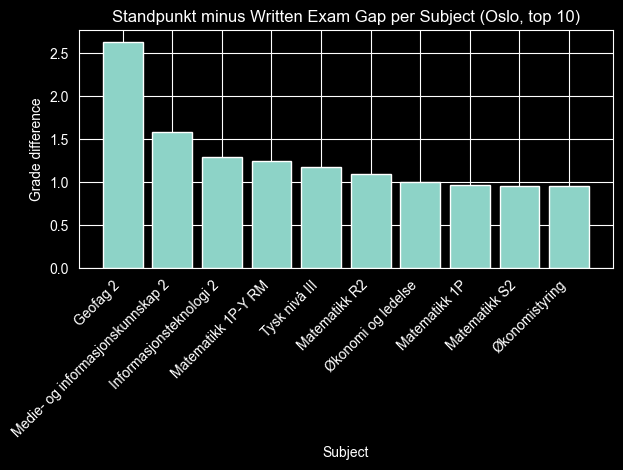

In [15]:
# Bar chart: grade gap per subject in Oslo
plt.bar(gap_by_subject.index, gap_by_subject.values)

plt.title("Standpunkt minus Written Exam Gap per Subject (Oslo, top 10)")
plt.xlabel("Subject")
plt.ylabel("Grade difference")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [16]:
# Calculate gap per school – shows which schools are strictest / most lenient
sp_by_school = standpunkt.groupby('Skole')['Snittkarakter'].mean()
sk_by_school = skriftlig.groupby('Skole')['Snittkarakter'].mean()

gap_by_school = (sp_by_school - sk_by_school).dropna().sort_values(ascending=False)

print("Standpunkt minus written exam gap per school (Oslo):")
print(gap_by_school)

Standpunkt minus written exam gap per school (Oslo):
Skole
Stovner videregående skole                                   1.355732
Akademiet Vgs Bislett AS                                     1.198990
Akademiet Oslo AS                                            1.198462
Hellerud videregående skole                                  1.158635
Eikelund videregående skole                                  1.087500
Bjørnholt videregående skole                                 1.047222
Vika videregående skole                                      1.044454
Bjerke videregående skole                                    1.032712
Heltberg private gymnas                                      0.992857
Etterstad videregående skole                                 0.909524
Otto Treider private gymnas AS                               0.872222
Persbråten videregående skole                                0.869787
Kongshavn videregående skole                                 0.855268
Fyrstikkalleen skole           

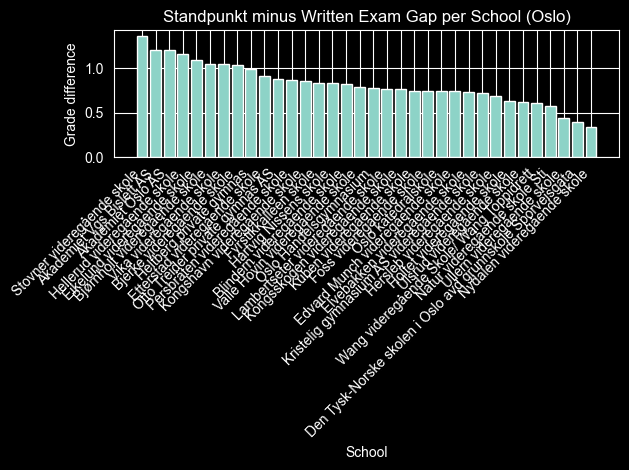

In [17]:
# Bar chart: gap per school – replicates the Aftenposten 'strict vs lenient' analysis
plt.bar(gap_by_school.index, gap_by_school.values)

plt.title("Standpunkt minus Written Exam Gap per School (Oslo)")
plt.xlabel("School")
plt.ylabel("Grade difference")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [18]:
# Also compare national level to Oslo
# EnhetNivaa == 1 = national level per subject
df_nat = df[(df['Nasjonalt'] == 'Hele landet') & (df['EnhetNivaa'] == 1)].copy()

snitt_nat = [
    c for c in df_nat.columns
    if 'Snittkarakter' in c and 'Brudd' not in c
]

df_nat_long = df_nat[['Vurderingsfagnavn'] + snitt_nat].melt(
    id_vars=['Vurderingsfagnavn'],
    value_vars=snitt_nat,
    var_name='col',
    value_name='Snittkarakter'
)

df_nat_long['Skoleaar'] = df_nat_long['col'].str.split('.').str[0]
df_nat_long['Vurderingsform'] = df_nat_long['col'].str.split('.').str[1]
df_nat_long = df_nat_long.drop(columns=['col'])

df_nat_long['Snittkarakter'] = (
    df_nat_long['Snittkarakter'].astype(str)
    .str.replace(',', '.', regex=False)
)
df_nat_long['Snittkarakter'] = pd.to_numeric(df_nat_long['Snittkarakter'], errors='coerce')
df_nat_long = df_nat_long.dropna(subset=['Snittkarakter'])
df_nat_recent = df_nat_long[df_nat_long['Skoleaar'].isin(recent_years)]

nat_sp = df_nat_recent[df_nat_recent['Vurderingsform'] == 'Standpunkt']['Snittkarakter'].mean()
nat_sk = df_nat_recent[df_nat_recent['Vurderingsform'] == 'Skriftlig eksamen']['Snittkarakter'].mean()

print(f"National average standpunkt:     {nat_sp:.2f}")
print(f"National average written exam:   {nat_sk:.2f}")
print(f"National gap:                    {nat_sp - nat_sk:.2f}")
print()
print(f"Oslo average standpunkt:         {avg_sp:.2f}")
print(f"Oslo average written exam:       {avg_sk:.2f}")
print(f"Oslo gap:                        {avg_sp - avg_sk:.2f}")

National average standpunkt:     4.33
National average written exam:   3.69
National gap:                    0.64

Oslo average standpunkt:         4.25
Oslo average written exam:       3.49
Oslo gap:                        0.76


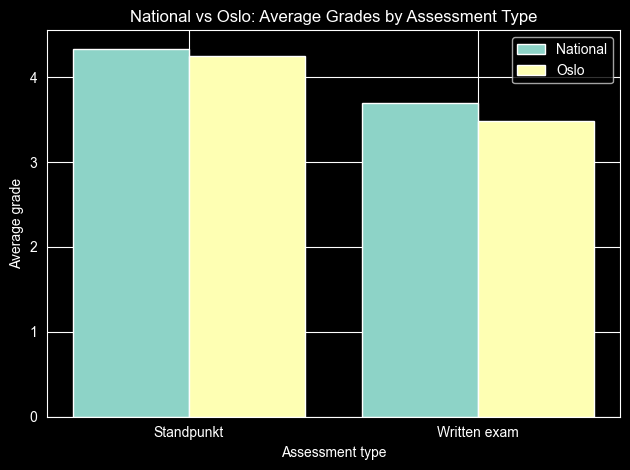

In [19]:
# Bar chart: national vs Oslo standpunkt and written exam averages
labels = ["Standpunkt", "Written exam"]
national_vals = [nat_sp, nat_sk]
oslo_vals = [avg_sp, avg_sk]

x = range(len(labels))

plt.bar([i - 0.2 for i in x], national_vals, width=0.4, label="National")
plt.bar([i + 0.2 for i in x], oslo_vals, width=0.4, label="Oslo")

plt.xticks(x, labels)
plt.title("National vs Oslo: Average Grades by Assessment Type")
plt.xlabel("Assessment type")
plt.ylabel("Average grade")
plt.legend()

plt.tight_layout()
plt.show()

## Findings

- Standpunkt grades are consistently higher than written exam grades, both nationally and in Oslo.
- Oral exam grades are higher than standpunkt grades.
- The gap varies by subject – mathematics and language subjects tend to show the largest standpunkt-exam gap.
- Oslo schools follow the same pattern as described in the Aftenposten article, but there is notable variation between individual schools.